### **EE 513 Homework 1**: _Setup and First Captures_  
Natalie Montano

#### **Course Environment**

##### **1. Smoke test results**

The course environment was built with the course-provided pyproject.toml file.

Smoke-test repository: https://github.com/nmmont/ee513-smoke-test

Printed output from codeblocks:

_Note: My laptop username is really called Test._

```Results:
Python   3.12.14
Platform Windows-10-10.0.19045-SP0
Executable C:\Users\Test\Documents\EE513\.venv\Scripts\python.exe

[PASS] all required packages import  numpy 2.5.3, scipy 1.18.1, matplotlib 3.11.2, cv2 5.0.0, rawpy 0.27.1, imageio 2.38.0, skimage 0.26.0

Not used until week 6, but the course environment installs them now: colour 0.4.7
  missing: torch, gradio - run `uv sync` again.

[PASS] OpenCV major version is 5  found 5.0.0
[PASS] you have the contrib build, not plain opencv-python  cv2.xfeatures2d present
[PASS] functions this course uses are present  7 of 7

#### **Project 1 Setup**

##### **2. Github Repository with readme** 
https://github.com/nmmont/camera_characterization

**Check which lens took the raw image:**

In [1]:
import os
import tifffile

# Standard numeric EXIF and TIFF tag IDs
MODEL_ID = 272             # Root TIFF tag for Device Model
FOCAL_LENGTH_ID = 37386    # Focal length tag
FOCAL_35MM_ID = 41989      # 35mm equivalent tag
F_NUMBER_ID = 33437        # F-Number tag

def lens_id(path):
    """The fingerprint of the camera that made this raw file."""
    with tifffile.TiffFile(path) as t:
        p = t.pages[0]
        
        # 1. Extract Device Model from root TIFF tags safely
        device_model = p.tags.get(MODEL_ID)
        if device_model:
            device_model = device_model.value
            if isinstance(device_model, bytes):
                device_model = device_model.decode('utf-8', errors='ignore').strip()
        else:
            device_model = "Google Pixel"

        # Extract metadata directory for sub-IFD tags
        if "ExifTag" in p.tags:
            exif = p.tags["ExifTag"].value
        else:
            exif = {tag.code: tag.value for tag in p.tags.values()}

        # 2. Extract Focal Length
        fl = exif.get(FOCAL_LENGTH_ID) or exif.get("FocalLength")
        if fl and isinstance(fl, (tuple, list)) and len(fl) == 2:
            calculated_fl = round(fl[0] / fl[1], 3)
        else:
            calculated_fl = fl if fl else 0.0
            
        # 3. Extract Aperture / F-Number
        f_num = exif.get(F_NUMBER_ID) or exif.get("FNumber")
        if f_num and isinstance(f_num, (tuple, list)) and len(f_num) == 2:
            calculated_f = round(f_num[0] / f_num[1], 2)
        else:
            calculated_f = f_num if f_num else None
            
        # 4. Extract 35mm Equivalent 
        focal_35mm = exif.get(FOCAL_35MM_ID) or exif.get("FocalLengthIn35mmFilm", None)
        
        # 5. Dimensions
        width = p.tags["ImageWidth"].value
        length = p.tags["ImageLength"].value
        
        return (device_model, calculated_fl, calculated_f, focal_35mm, (width, length))

def assert_one_camera(paths):
    ids = {lens_id(p) for p in paths}
    if len(ids) != 1:
        raise SystemExit(f"more than one camera in this series:\n  " +
                         "\n  ".join(map(str, ids)))
    return ids.pop()

#set test image path
path = ["../Images/IMG_20261005_002056.dng"]
valid_paths = [p for p in path if os.path.exists(p)]

if not valid_paths:
    print(f"Error: Target raw file paths do not exist on disk.")
else:
    camera_fingerprint = assert_one_camera(valid_paths)
    print("Camera Lens Profile:")
    print(f"  Device Model:    {camera_fingerprint[0]}")
    print(f"  Focal Length:    {camera_fingerprint[1]} mm")
    print(f"  F-stop:          f/{camera_fingerprint[2]}")
    print(f"  35mm Equivalent: {camera_fingerprint[3]} mm")
    print(f"  Sensor Shape:    {camera_fingerprint[4]} (Width x Height)")


Camera Lens Profile:
  Device Model:    Pixel 9
  Focal Length:    6.9 mm
  F-stop:          f/1.68
  35mm Equivalent: None mm
  Sensor Shape:    (4080, 3072) (Width x Height)


##### **3. Confirm the camera writes real raw images**

In [2]:
import rawpy

#set test image path
folder_path = "../Images"
base_name = "IMG_20261005_002056"
img_dng = os.path.join(folder_path, f"{base_name}.dng")

print(f"File Name: {os.path.basename(img_dng)}")
with rawpy.imread(img_dng) as raw:
    print("Raw_type:", raw.raw_type)
    print("Raw_image_shape:", raw.raw_image_visible.shape)
    print("Raw_image_dtype:", raw.raw_image_visible.dtype)
    print("Raw_pattern:", raw.raw_pattern)
    print("Color_desc:", raw.color_desc)
    print("Black_level_per_channel:", raw.black_level_per_channel)
    print("White_level:", raw.white_level)

    

File Name: IMG_20261005_002056.dng
Raw_type: RawType.Flat
Raw_image_shape: (3072, 4080)
Raw_image_dtype: uint16
Raw_pattern: [[3 2]
 [0 1]]
Color_desc: b'RGBG'
Black_level_per_channel: [63, 63, 63, 63]
White_level: 1023


##### **4. Check Bayer mosaic**

The camera captures DNG images as a Bayer mosaics because the raw_type is flat and has not been interpolated, has a 2D shape (Height and Width), and it has a 2X2 matrix pattern. 

CFA: GRBG


##### **5. Not applicable**

##### **6. Raw vs JPEG Information**

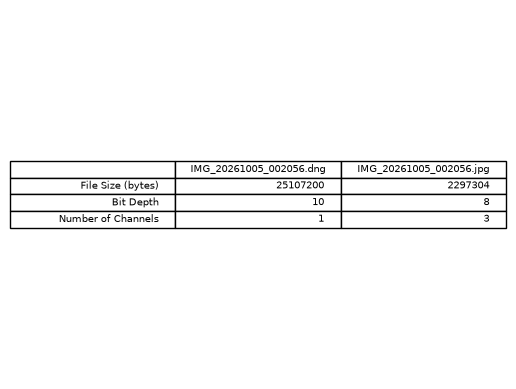

In [3]:
import cv2
import matplotlib.pyplot as plt

img_jpg = os.path.join(folder_path, f"{base_name}.jpg")

#DNG
raw_size = os.path.getsize(img_dng)
with rawpy.imread(img_dng) as raw:
    raw_bit_depth = raw.white_level.bit_length()
    raw_shape = raw.raw_image_visible.shape
    raw_channels = 1 if len(raw_shape) == 2 else raw_shape[2]

#JPG
jpg_size = os.path.getsize(img_jpg)
jpg_img = cv2.imread(img_jpg, cv2.IMREAD_UNCHANGED)
jpg_channels = 1 if len(jpg_img.shape) == 2 else jpg_img.shape[2]
jpg_bit_depth = jpg_img.dtype.itemsize*8 #bits

#table
table_data = [
    ["File Size (bytes)", raw_size, jpg_size],
    ["Bit Depth", raw_bit_depth, jpg_bit_depth],
    ["Number of Channels", str(raw_channels), str(jpg_channels)] 
]

headers = ["", f"{base_name}.dng", f"{base_name}.jpg"]

fig, ax = plt.subplots()
ax.axis('off')
ax.table(cellText=table_data, colLabels=headers, loc='center')

plt.show()

##### **7. 30x30 Raw Data Zoom**

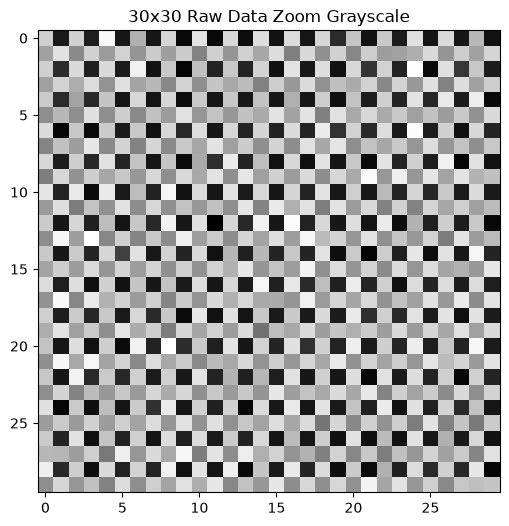

In [4]:
with rawpy.imread(img_dng) as raw:
    raw_data = raw.raw_image_visible.copy()

height, width = raw_data.shape

#around the center of the image
u = width // 2 #column
v = height // 2 #row

#crop by 30x30 region in the u and v direction
crop_30 = raw_data[v : v + 30, u : u+30]

plt.figure(figsize =(6,6))
plt.imshow(crop_30, cmap="gray")
plt.title("30x30 Raw Data Zoom Grayscale")
plt.axis('on')
plt.show()

The checkerboard texture is the physical Bayer mosaic CFA pattern where the boxes represent pixel brightness in a repeating 2x2 GBRG pattern.

##### **8. Information Lost**



From question 6’s table, we can see that the image went from one channel to three channels (demosaicing and interpolation fills in missing values) so the raw intensity values were lost as it was translated into a jpg (Bhandari et all, 2022). This is irreversible because there are many different number combinations that can recreate those interpolated pixel values.

We can also see that bit depth is reduced from 10 bits to to 8-bits which loses detail on intensity (for mine it is 63 (dark) to 1023 (light) in the raw DNG but only 0 to 255 for the jpg). This is irreversible because those exact intensity values cannot be retrieved once they are scaled down.

Finally, there is also a reduction in the file size (25 mb in raw vs 2 mb in jpg) meaning data is deleted. This is irreversible because it cannot retrieve data that has already been removed.


#### **First Calibration Captures**

##### **9. Calibration Target**

In [5]:
SQUARE_MM = 19

The physical measurement for the width and height for each square measured 19.0 ± 0.5 mm. Due to printer/printer software rescaling the calibration target, I measured each square then took their average mm length for both axes. The measured value is needed because accurate physical units are necessary for calibration.

##### **10. Contact sheet**

Success! Contact sheet saved to disk as: hw1_contact_sheet.jpg



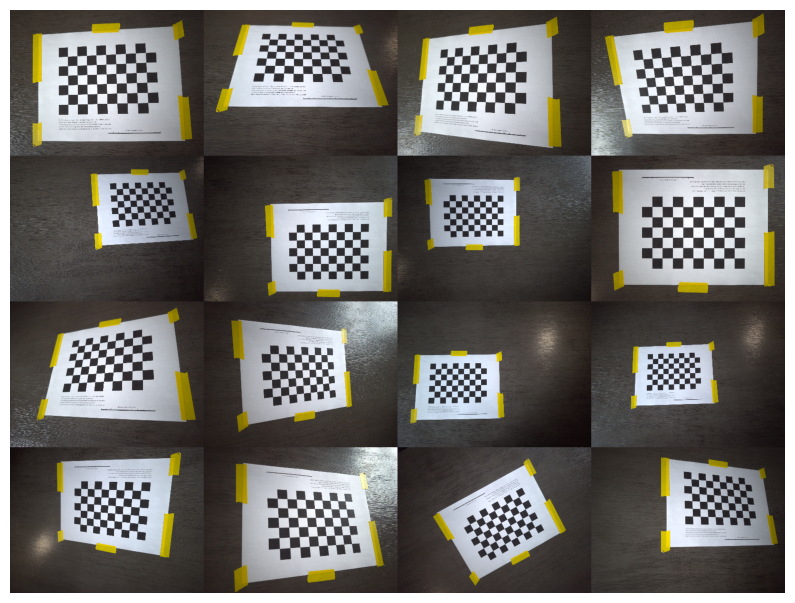

In [6]:
import glob
import numpy as np

#Set calibration folder
dng_files = sorted(glob.glob("../Calibration_Captures/*.dng"))

cols = 4
size = (width // 10, height // 10)  # scale down the width and height by 10
thumbnails = []

for path in dng_files:
    try:
        with rawpy.imread(path) as raw:
            rgb = raw.postprocess(use_camera_wb=True)
            bgr = cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)

            #check orientation and rotate vertical images
            h, w, _ = bgr.shape
            if h > w:
                bgr = cv2.rotate(bgr, cv2.ROTATE_90_CLOCKWISE)

            resized = cv2.resize(bgr, size)
            thumbnails.append(resized)
    except Exception as e:
        print(f"Skipping broken file {path}: {e}")

if not thumbnails:
    print("Error: Found DNG files, but rawpy could not process any of them.")
else:
    #Fill leftovers with blank black cells
    while len(thumbnails) % cols != 0:
        thumbnails.append(np.zeros((size[1], size[0], 3), dtype=np.uint8))

    #Snap rows and columns together safely
    rows = [np.hstack(thumbnails[i:i+cols]) for i in range(0, len(thumbnails), cols)]
    contact_sheet = np.vstack(rows)

    #Save
    output_filename = "hw1_contact_sheet.jpg"
    cv2.imwrite(output_filename, contact_sheet)
    print(f"Success! Contact sheet saved to disk as: {output_filename}\n")
    
    #render to console
    rgb_display = cv2.cvtColor(contact_sheet, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(10, 10))  # Scale the size of the inline window frame
    plt.imshow(rgb_display)
    plt.axis('off')               # Hide the chart grid axis numbers
    plt.show()


##### **11. ChessboardCorners Check**

Success: 16 out of 16 gave a full (9,6) grid


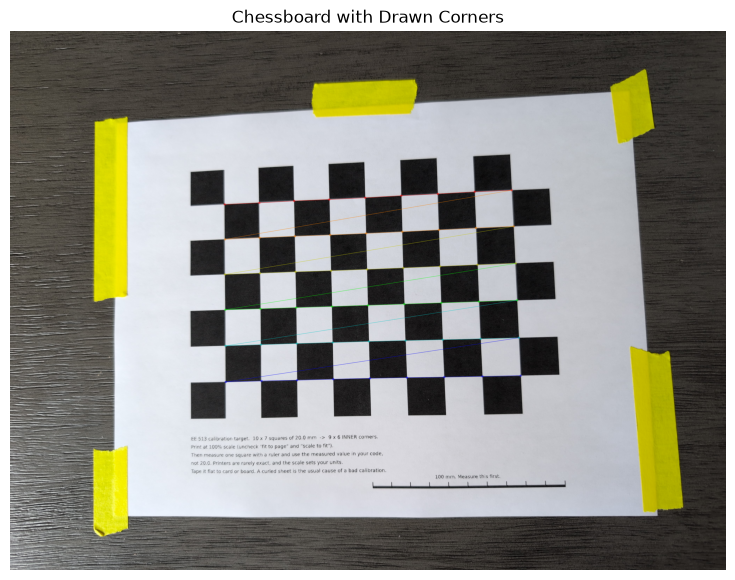

In [7]:
calibration_folder = "../Calibration_Captures"
pattern_size = (9,6)

def chessboard(folder, pattern_size):
    success = 0
    success_img = None
    img_paths = glob.glob(os.path.join(folder, '*.jpg'))
    total = len(img_paths)

    for path in img_paths:
        img = cv2.imread(path)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        retval, corners = cv2.findChessboardCorners(gray, pattern_size, cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_NORMALIZE_IMAGE)

        if retval:
            success += 1

            if success_img is None:
                img_color = cv2.imread(path)
                cv2.drawChessboardCorners(img_color, pattern_size, corners, retval)
                success_img = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)
    return success, success_img, total

success, success_img, total = chessboard(calibration_folder, pattern_size)
print(f"Success: {success} out of {total} gave a full (9,6) grid")

if success_img is not None:
    plt.figure(figsize=(10, 7))
    plt.imshow(success_img)
    plt.title("Chessboard with Drawn Corners")
    plt.axis("off")
    plt.show()

##### **12. RMS Reprojection**

In [9]:
def calibrate_camera(folder, pattern_size, SQUARE_MM):
    # Check successful captures
    success, success_img, total = chessboard(folder, pattern_size)
    if success == 0:
        print("No successful detections.")
        return None

    objp = np.zeros((pattern_size[0] * pattern_size[1], 3), np.float32)
    objp[:, :2] = np.mgrid[0 : pattern_size[0], 0 : pattern_size[1]].T.reshape(-1, 2)
    objp *= SQUARE_MM

    objpoints = []  # 3D points - irl
    imgpoints = []  # 2D points - image
    img_size = None

    #criteria from lecture #2
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

    img_paths = glob.glob(os.path.join(folder, "*.jpg"))
    for path in img_paths:
        img = cv2.imread(path)
        if img is None:
            continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        if img_size is None:
            img_size = (gray.shape[1], gray.shape[0])  # (width, height)

        retval, corners = cv2.findChessboardCorners(gray, pattern_size, cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_NORMALIZE_IMAGE)

        if retval:
            corners_subpix = cv2.cornerSubPix(gray, corners, (11, 11), (-1, -1), criteria)
            objpoints.append(objp)
            imgpoints.append(corners_subpix)

    #check detection points
    if not objpoints or not imgpoints:
        print("Failed to find valid chessboard corners in loaded images.")
        return None

    rms_error, camera_matrix, dist_coeffs, rvecs, tvecs = cv2.calibrateCamera(
        objpoints, imgpoints, img_size, None, None
    )

    return rms_error

rms_error = calibrate_camera(calibration_folder, pattern_size, SQUARE_MM)
if rms_error is not None:
    print(f"RMS Reprojection Error: {rms_error:.4f} px")

RMS Reprojection Error: 3.5358 px


The RMS reprojection error is the offset of pixels between the predicted location of a pixel at a corner and where it was on the actual image.

### **Reflection**

#### **13. What I learned**

Bayer mosaic: A bayer mosaic is a color filter array of 2x2 GRBG (2 greens, 1 red, and 1 blue). Each pixel represents the intensity of the light that has passed through that specific color filter. So for instance, at the location of a green filter, only green light can pass so Red and Blue do not have values. 

Demosaic: I looked into the book to understand what happens when we go from 1 channel to 3 channels and I learned that demosaicing is the name of that process and interpolation occurs when information from neighboring pixels are utilized to fill in the blank values of the other channels for a single pixel.

Information reduction: The conversion from a raw image to a jpg inherently loses information in order to display three color channels aka images meant for the human eye.



#### **14. Remaining questions**

When the size of the file is reduced, what else is getting lost? Can you predict how much an image will be reduced by?

#### **Use of AI:**

I utilized Gemini AI to help with setting up the figures/contact sheet on my notebook as well as getting help with syntax/bugs. I also utilized AI to help me verify the exif information from my dng because I had issues with that codeblock from lecture 2. I verified it by checking the image details/properties through file explorer. 